##### Le chargement des bibliotech 

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder


#### le chargement de dataset 

In [19]:
df_init = pd.read_csv("../data/raw/data_initial.csv")
# df_init.isnull().sum()
df_init.duplicated().sum()   
# df_init.columns


service_cols = [
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

In [20]:
df = df_init.drop(["customerID","Partner","Dependents","gender"],axis=1)


# print(df.shape)
# print(df.columns)

df = df.replace(" ", np.nan)
# df.isnull().sum()

mediane_total_charges = df["TotalCharges"].astype(float).median()

df["TotalCharges"] = df["TotalCharges"].fillna(
    mediane_total_charges
)
# df.isnull().sum()

df.duplicated().sum()


df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)


df["Churn"].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

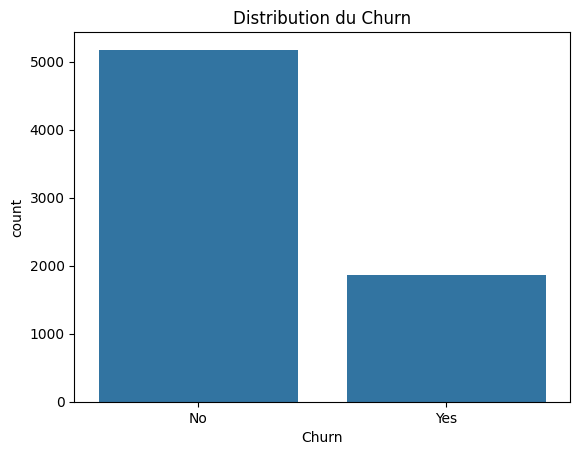

In [21]:
sns.countplot(data=df, x="Churn")
plt.title("Distribution du Churn")
plt.show()

In [22]:
numeric = df.select_dtypes(
    include=['int64','float64']
).columns
print(numeric)

# df[numeric].describe()

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')


In [23]:
categorical_cols = df.select_dtypes(
    include="object"
).columns

print(categorical_cols)


Index(['PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'Churn'],
      dtype='object')


In [24]:
Q1_montlhy = df["MonthlyCharges"].quantile(0.25)
Q3_montlhy = df["MonthlyCharges"].quantile(0.75)

IQR_montlhy = Q3_montlhy - Q1_montlhy

lower_montlhy = Q1_montlhy - 1.5 * IQR_montlhy
upper_montlhy = Q3_montlhy + 1.5 * IQR_montlhy

outlier_montlhy = df[
    (df["MonthlyCharges"]< lower_montlhy)|
    (df["MonthlyCharges"]>upper_montlhy)
]

outlier_montlhy.to_csv("../data/test/outlier_montlhy.csv",index=False)


In [25]:
Q1_total_charge  = df["TotalCharges"].quantile(0.25)
Q3_total_charge  = df["TotalCharges"].quantile(0.75)


IQR_total_charge = Q3_total_charge - Q1_total_charge

lower_total_charge = Q1_total_charge - 1.5 *IQR_total_charge
upper_total_charge = Q3_total_charge + 1.5 *IQR_total_charge

outlier_total_charge = df[
    (df["TotalCharges"] < lower_total_charge)|
    (df["TotalCharges"] > upper_total_charge)
]

outlier_total_charge.to_csv("../data/test/outlier_total_charge.csv")


In [26]:
Q1_tenure  = df["tenure"].quantile(0.25)
Q3_tenure  = df["tenure"].quantile(0.75)


IQR_tenure = Q3_tenure - Q1_tenure

lower_tenure = Q1_tenure - 1.5 *IQR_tenure
upper_tenure = Q3_tenure + 1.5 *IQR_tenure

outlier_tenure = df[
    (df["tenure"] < lower_tenure)|
    (df["tenure"] > upper_tenure)
]

outlier_tenure.to_csv("../data/test/outlier_tenure.csv")


In [27]:
churn_by_contract = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

print(churn_by_contract.round(2))

Churn              No    Yes
Contract                    
Month-to-month  57.29  42.71
One year        88.73  11.27
Two year        97.17   2.83


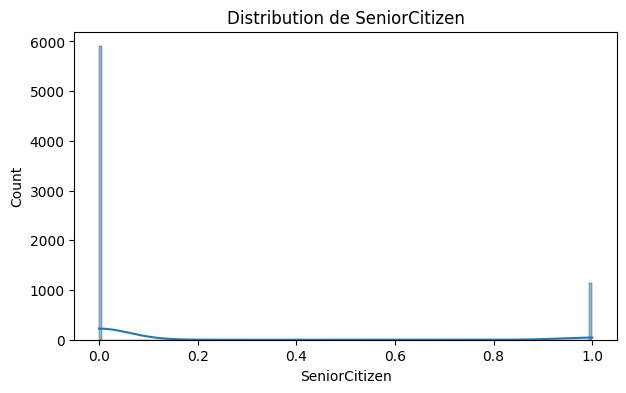

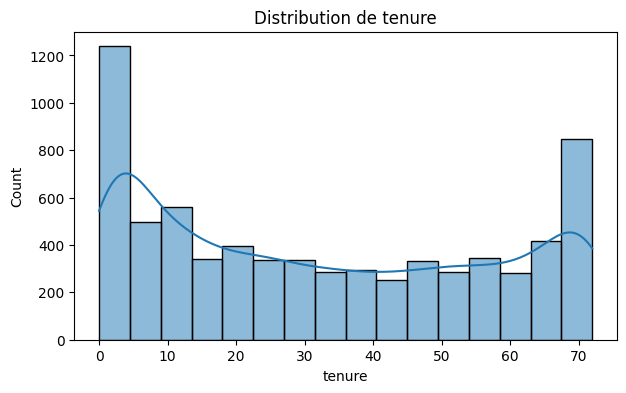

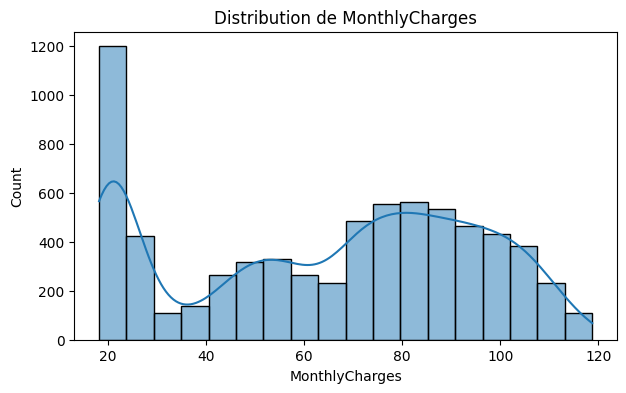

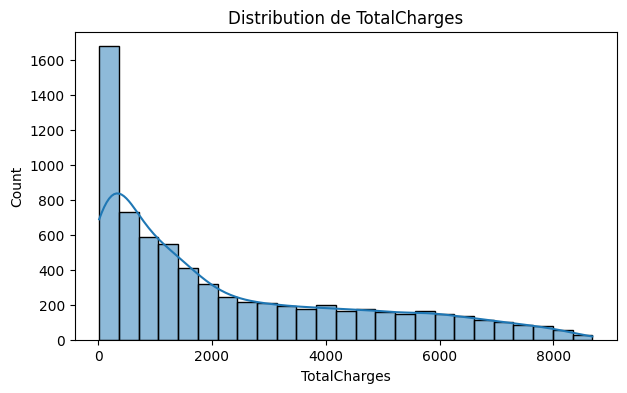

In [28]:
numeric_cols = [
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

for col in numeric_cols:
    plt.figure(figsize=(7, 4))

    sns.histplot(
        data=df,
        x=col,
        kde=True
    )

    plt.title(f"Distribution de {col}")
    plt.show()

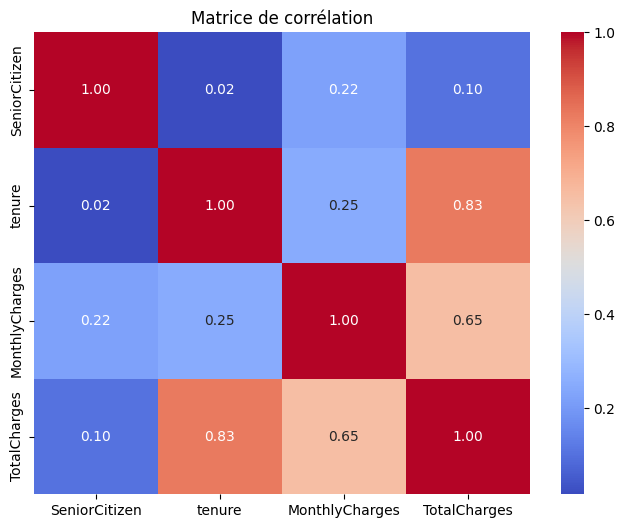

In [29]:
corr = df[numeric_cols].corr()
# corr

plt.figure(figsize=(8, 6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Matrice de corrélation")
plt.show()

In [30]:
# # df["gender"].value_counts()
# # df["MultipleLines"].value_counts()
# df["PaymentMethod"].value_counts()


In [31]:
service_cols = [
    "PhoneService",
    "MultipleLines",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

df["num_services"] = df[service_cols].eq("Yes").sum(axis=1)


In [32]:
# print(df_clustring)

df.to_csv("../data/processed/clean_data.csv",index=False)

In [33]:
# df["gender"].value_counts(normalize=True)*100
df["Churn"].value_counts(normalize=True)*100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64